In [1]:
# # ! Setup
import numpy as np
import pandas as pd
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt
import pyvista as pv
import time
from datetime import datetime
from gravity_forward_numba import *

In [2]:
# # ! Functions
def fibonacci_sphere_points(N, radius=1.0):
    """Generate N approximately uniformly distributed points on a sphere."""
    i = np.arange(N, dtype=np.float64)
    phi = np.arccos(1.0 - 2.0 * (i + 0.5) / N)
    theta = np.pi * (1.0 + 5.0**0.5) * (i + 0.5)
    x = radius * np.sin(phi) * np.cos(theta)
    y = radius * np.sin(phi) * np.sin(theta)
    z = radius * np.cos(phi)
    return np.column_stack((x, y, z))

In [3]:
# # ! Start time
print("=" * 80)
print(f"Start time: [{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}]")
print("=" * 80)

Start time: [2026-04-25 13:57:08]


In [4]:
# # ! Earth model (km, kg/m³)
r_e = 6371.393      # mean Earth radius [km]
rho_e = 5520.0      # mean Earth density [kg/m³]

# Homogeneous sphere
xc, yc, zc = 0.0, 0.0, 0.0
a = r_e
rho = rho_e

# Observation altitudes (km)
alts = [0.001, 0.1, 1.0, 10.0]
r_obs_list = [r_e + h for h in alts]

# Use Fibonacci sampling instead of lat/lon grid
nobs = 100  # number of observation points per altitude
print(f"\nUsing Fibonacci sphere sampling with {nobs} points per altitude\n")

# Store observation points and reference solutions
P_list = []
ref_list = []

for r in r_obs_list:
    P = fibonacci_sphere_points(nobs, radius=r)
    P_list.append(P)
    
    x, y, z = P[:,0], P[:,1], P[:,2]
    r_vec = np.sqrt(x**2 + y**2 + z**2)
    lat_rad = np.arcsin(z / r_vec)
    lon_rad = np.arctan2(y, x)
    
    # Analytical solution
    V_ref, gx_ref, gy_ref, gz_ref, Txx_ref, Txy_ref, Txz_ref, Tyy_ref, Tyz_ref, Tzz_ref = \
        gsphere(x, y, z, xc, yc, zc, a, rho)
    
    # Rotate to NED
    gN_ref, gE_ref, gD_ref, TNN_ref, TNE_ref, TND_ref, TEE_ref, TED_ref, TDD_ref = \
        rotate_vec_ten_ecef2ned(
            lon_rad, lat_rad,
            gx_ref, gy_ref, gz_ref,
            Txx_ref, Txy_ref, Txz_ref,
            Tyy_ref, Tyz_ref, Tzz_ref
        )
    
    ref_list.append([V_ref, gN_ref, gE_ref, gD_ref,
                     TNN_ref, TNE_ref, TND_ref, TEE_ref, TED_ref, TDD_ref])

fields = ['V', 'gN', 'gE', 'gD', 'TNN', 'TNE', 'TND', 'TEE', 'TED', 'TDD']

# Mesh refinement
nsub_max = 10
NSUBs = np.arange(nsub_max + 1)
Lon_Res = 5 * (2 ** NSUBs)
Lat_Res = (2 ** (NSUBs + 1)) + 2

# Results containers
err_ico_all = []
err_geo_all = []
time_ico_all = []
time_geo_all = []
ref_vals_all = []


Using Fibonacci sphere sampling with 100 points per altitude



In [5]:
# # ! Loop over altitudes
for i, (P, refs) in enumerate(zip(P_list, ref_list)):
    h = alts[i]
    print(f"\n=== Altitude: {h:g} km ===")
    
    err_ico = {f: [] for f in fields}
    err_geo = {f: [] for f in fields}
    t_ico = []
    t_geo = []
    
    x, y, z = P[:,0], P[:,1], P[:,2]
    r_obs = np.sqrt(x**2 + y**2 + z**2)
    lat_rad = np.arcsin(z / r_obs)
    lon_rad = np.arctan2(y, x)
    
    for j, nsub in enumerate(NSUBs):
        print(f"  Processing nsub = {nsub}... [{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}]")
        
        # --- Icosphere ---
        mesh = pv.Icosphere(radius=a, center=(xc, yc, zc), nsub=nsub)
        verts = mesh.points
        faces = mesh.regular_faces
        
        t0 = time.time()
        V, gx, gy, gz, Txx, Txy, Txz, Tyy, Tyz, Tzz = WerSch_numba_v2(P, verts, faces, rho)
        t_ico.append(time.time() - t0)
        
        gN, gE, gD, TNN, TNE, TND, TEE, TED, TDD = rotate_vec_ten_ecef2ned(
            lon_rad, lat_rad, gx, gy, gz, Txx, Txy, Txz, Tyy, Tyz, Tzz)
        cal_ico = [V, gN, gE, gD, TNN, TNE, TND, TEE, TED, TDD]
        
        for f, ref, cal in zip(fields, refs, cal_ico):
            rms_ref = np.linalg.norm(ref) / np.sqrt(ref.size)
            rms_err = np.linalg.norm(cal - ref) / np.sqrt(cal.size)
            err = rms_err if rms_ref < 1e-8 else rms_err / rms_ref
            err_ico[f].append(err)

        # --- Geographic grid ---
        mesh = pv.Sphere(radius=a, center=(xc, yc, zc),
                         theta_resolution=Lon_Res[j],
                         phi_resolution=Lat_Res[j])
        verts = mesh.points
        faces = mesh.regular_faces

        t0 = time.time()
        V, gx, gy, gz, Txx, Txy, Txz, Tyy, Tyz, Tzz = WerSch_numba_v2(P, verts, faces, rho)
        t_geo.append(time.time() - t0)
        
        gN, gE, gD, TNN, TNE, TND, TEE, TED, TDD = rotate_vec_ten_ecef2ned(
            lon_rad, lat_rad, gx, gy, gz, Txx, Txy, Txz, Tyy, Tyz, Tzz)
        cal_geo = [V, gN, gE, gD, TNN, TNE, TND, TEE, TED, TDD]
        
        for f, ref, cal in zip(fields, refs, cal_geo):
            rms_ref = np.linalg.norm(ref) / np.sqrt(ref.size)
            rms_err = np.linalg.norm(cal - ref) / np.sqrt(cal.size)
            err = rms_err if rms_ref < 1e-8 else rms_err / rms_ref
            err_geo[f].append(err)
    
    err_ico_all.append(err_ico)
    err_geo_all.append(err_geo)
    time_ico_all.append(t_ico)
    time_geo_all.append(t_geo)
    ref_vals_all.append({f: np.mean(r) for f, r in zip(fields, refs)})


=== Altitude: 0.001 km ===
  Processing nsub = 0... [2026-04-25 13:57:08]
  Processing nsub = 1... [2026-04-25 13:57:10]
  Processing nsub = 2... [2026-04-25 13:57:10]
  Processing nsub = 3... [2026-04-25 13:57:10]
  Processing nsub = 4... [2026-04-25 13:57:10]
  Processing nsub = 5... [2026-04-25 13:57:10]
  Processing nsub = 6... [2026-04-25 13:57:10]
  Processing nsub = 7... [2026-04-25 13:57:10]
  Processing nsub = 8... [2026-04-25 13:57:10]
  Processing nsub = 9... [2026-04-25 13:57:12]
  Processing nsub = 10... [2026-04-25 13:57:17]

=== Altitude: 0.1 km ===
  Processing nsub = 0... [2026-04-25 13:57:42]
  Processing nsub = 1... [2026-04-25 13:57:42]
  Processing nsub = 2... [2026-04-25 13:57:42]
  Processing nsub = 3... [2026-04-25 13:57:42]
  Processing nsub = 4... [2026-04-25 13:57:42]
  Processing nsub = 5... [2026-04-25 13:57:42]
  Processing nsub = 6... [2026-04-25 13:57:42]
  Processing nsub = 7... [2026-04-25 13:57:42]
  Processing nsub = 8... [2026-04-25 13:57:43]
  Pro

In [6]:
# # ! Print results tables
for i, h in enumerate(alts):
    df_ico = pd.DataFrame(err_ico_all[i], index=NSUBs)
    df_ico['Time (s)'] = time_ico_all[i]

    df_geo = pd.DataFrame(err_geo_all[i], index=NSUBs)
    df_geo['Time (s)'] = time_geo_all[i]

    print("\n" + "=" * 80)
    print(f"Altitude = {h:g} km — Icosphere vs Analytical "
          f"({nobs} obs pts)")
    print("=" * 80)
    print(df_ico.to_string(float_format="{:.2e}".format))

    print("\n" + "=" * 80)
    print(f"Altitude = {h:g} km — Geographic Grid vs Analytical "
          f"({nobs} obs pts)")
    print("=" * 80)
    print(df_geo.to_string(float_format="{:.2e}".format))

print("\n" + "=" * 80)
print("Reference Values at Different Altitudes")
print("GP in m²/s², GV in mGal, GGT in Eotvos")
print("=" * 80)
df_refs = pd.DataFrame(ref_vals_all, index=alts)
print(df_refs.to_string(float_format="{:8.2f}".format))


Altitude = 0.001 km — Icosphere vs Analytical (100 obs pts)
          V       gN       gE       gD      TNN      TNE      TND      TEE      TED      TDD  Time (s)
0  3.95e-01 1.25e+04 1.30e+04 3.95e-01 4.04e-01 7.52e+01 1.80e+02 4.09e-01 1.82e+02 4.04e-01  1.28e+00
1  1.27e-01 7.65e+03 7.07e+03 1.27e-01 1.56e-01 6.99e+01 1.74e+02 1.54e-01 1.53e+02 1.46e-01  6.23e-04
2  3.39e-02 2.78e+03 2.56e+03 3.41e-02 6.43e-02 4.96e+01 1.08e+02 6.58e-02 1.04e+02 5.67e-02  1.03e-03
3  8.62e-03 7.40e+02 7.55e+02 8.70e-03 3.04e-02 2.90e+01 6.11e+01 3.18e-02 5.93e+01 2.55e-02  4.78e-03
4  2.16e-03 2.14e+02 2.01e+02 2.17e-03 1.63e-02 1.62e+01 3.37e+01 1.76e-02 3.28e+01 1.38e-02  3.48e-03
5  5.42e-04 5.47e+01 5.02e+01 5.56e-04 8.35e-03 7.94e+00 1.62e+01 7.59e-03 1.57e+01 6.29e-03  1.09e-02
6  1.36e-04 1.18e+01 1.34e+01 1.40e-04 4.15e-03 4.39e+00 7.52e+00 4.03e-03 8.49e+00 3.26e-03  3.59e-02
7  3.38e-05 3.26e+00 3.24e+00 3.46e-05 2.19e-03 2.17e+00 4.37e+00 2.46e-03 4.20e+00 1.91e-03  1.30e-01
8  8.44e-06 

In [7]:
# # ! Save & Load Data
# >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
# UNCOMMENT THIS BLOCK TO SKIP COMPUTATION AND RELOAD FOR PLOTTING ONLY
# <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<

# Load data
# data = np.load(f'IcoGeoSphere_Global_nsub{nsub_max}_nobs{nobs}.npz', 
#                allow_pickle=True)
# nsub_max = int(data['nsub_max'])
# nobs = int(data['nobs'])
# alts = data['alts']
# NSUBs = data['NSUBs']
# err_ico_all = [dict(item) for item in data['err_ico_all']]
# err_geo_all = [dict(item) for item in data['err_geo_all']]
# time_ico_all = data['time_ico_all']
# time_geo_all = data['time_geo_all']
# ref_vals_all = [dict(item) for item in data['ref_vals_all']]
# fields = data['fields'].tolist()


# Save data
# np.savez_compressed(
#     f'IcoGeoSphere_Global_nsub{nsub_max}_nobs{nobs}.npz',
#     nsub_max=nsub_max,
#     nobs=nobs,
#     alts=alts,
#     NSUBs=NSUBs,
#     err_ico_all=err_ico_all,
#     err_geo_all=err_geo_all,
#     time_ico_all=time_ico_all,
#     time_geo_all=time_geo_all,
#     ref_vals_all=ref_vals_all,
#     fields=fields
# )

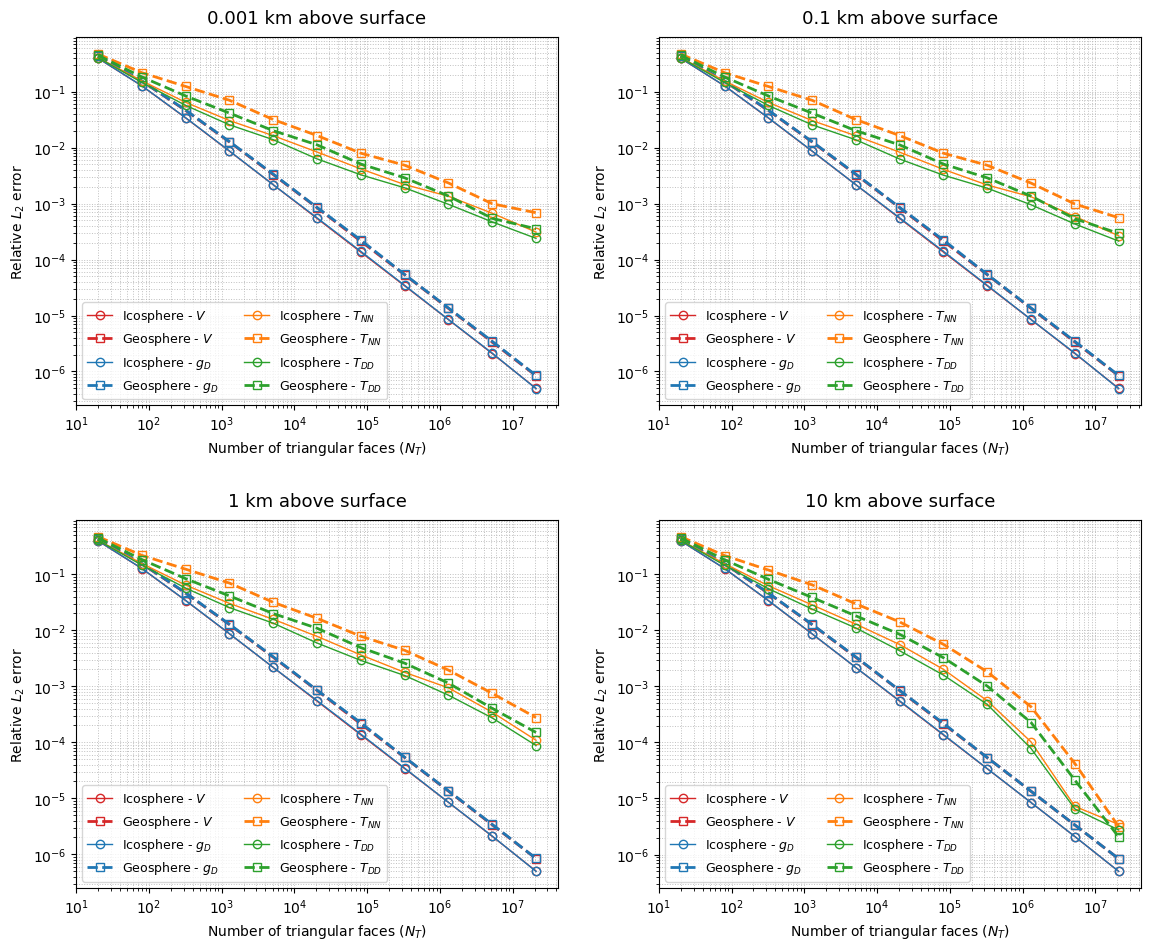

In [8]:
# # ! Plot representative fields for each altitude
rep_fields = ['V', 'gD', 'TNN', 'TDD']
labels = {'V': r'$V$', 'gD': r'$g_D$', 'TNN': r'$T_{NN}$', 'TDD': r'$T_{DD}$'}
colors = {'V': 'tab:red', 'gD': 'tab:blue', 'TNN': 'tab:orange', 'TDD': 'tab:green'}

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.flatten()

NTs = 20 * (4 ** NSUBs)

for i, h in enumerate(alts):
    ax = axs[i]
    for field in rep_fields:
        c = colors[field]
        lbl = labels[field]
        ax.loglog(NTs, err_ico_all[i][field], '-', marker='o', fillstyle='none',
                  color=c, linewidth=1, markersize=6, label=f'Icosphere - {lbl}')
        ax.loglog(NTs, err_geo_all[i][field], '--', marker='s', fillstyle='none',
                  color=c, linewidth=2, markersize=6, label=f'Geosphere - {lbl}')
    
    ax.set_title(f'{h:g} km above surface', fontsize=13, pad=10)
    ax.set_xlabel('Number of triangular faces ($N_T$)')
    ax.set_ylabel('Relative $L_2$ error')
    ax.grid(True, which="both", linestyle=':', linewidth=0.7, alpha=0.8)
    ax.legend(fontsize=9, loc='lower left', frameon=True, ncol=2)

plt.tight_layout(pad=2.5)
# plt.savefig(f"IcoGeoSphere_Global_nsub{nsub_max}_nobs{nobs}.png", 
#             dpi=300, bbox_inches='tight')
plt.show()

In [9]:
# # ! End time
print("=" * 80)
print(f"End time: [{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}]")
print("=" * 80)

End time: [2026-04-25 13:59:26]
